<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml(skill_8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset uploaded successfully!
File: placement_predict_50k Dataset.csv
Dataset Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Rows available for training: 43684

Training samples: 32763
Testing samples: 10921
gini     train=1.000 test=0.889 leaves=2774
entropy  train=1.000 test=0.891 leaves=2676


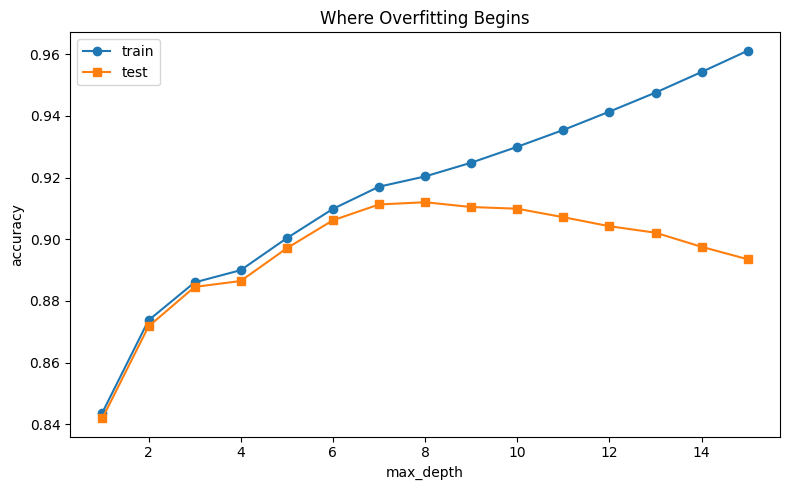


unpruned: leaves=2774 test=0.8888
pruned  : leaves=80   test=0.9125

Classification Report:

              precision    recall  f1-score   support

          No       0.88      0.86      0.87      3738
         Yes       0.93      0.94      0.93      7183

    accuracy                           0.91     10921
   macro avg       0.90      0.90      0.90     10921
weighted avg       0.91      0.91      0.91     10921



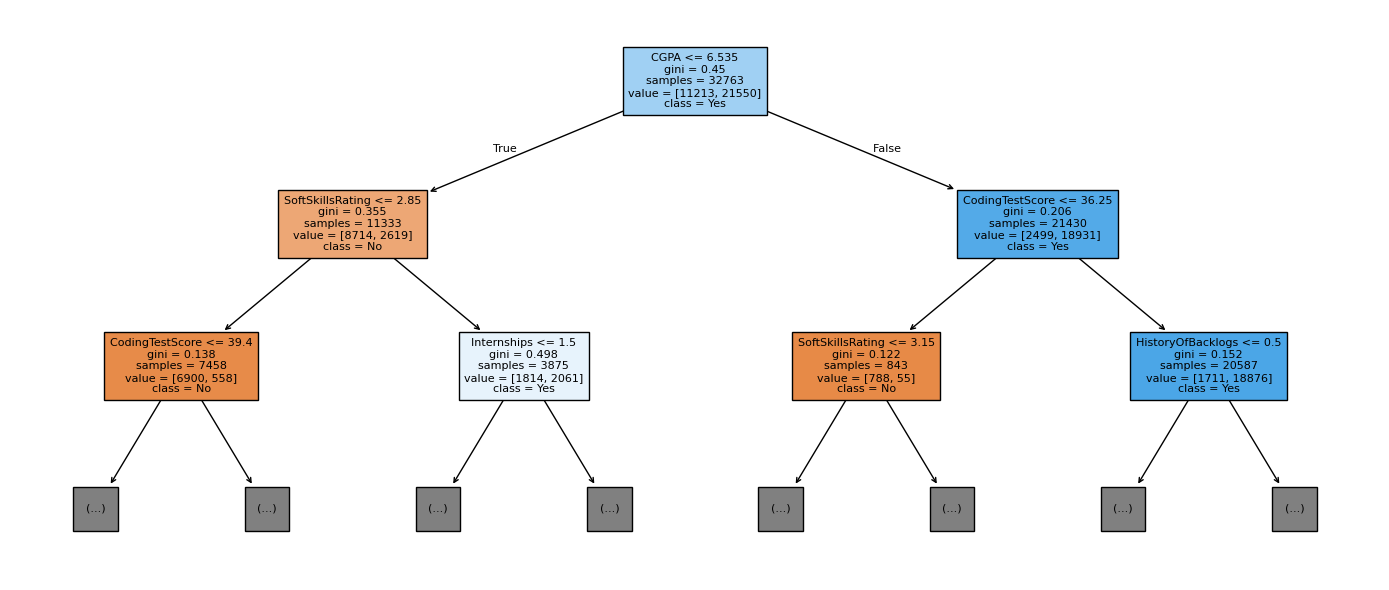

|--- CGPA <= 6.54
|   |--- SoftSkillsRating <= 2.85
|   |   |--- CodingTestScore <= 39.40
|   |   |   |--- truncated branch of depth 4
|   |   |--- CodingTestScore >  39.40
|   |   |   |--- truncated branch of depth 7
|   |--- SoftSkillsRating >  2.85
|   |   |--- Internships <= 1.50
|   |   |   |--- truncated branch of depth 9
|   |   |--- Internships >  1.50
|   |   |   |--- truncated branch of depth 7
|--- CGPA >  6.54
|   |--- CodingTestScore <= 36.25
|   |   |--- SoftSkillsRating <= 3.15
|   |   |   |--- truncated branch of depth 2
|   |   |--- SoftSkillsRating >  3.15
|   |   |   |--- class: 1
|   |--- CodingTestScore >  36.25
|   |   |--- HistoryOfBacklogs <= 0.50
|   |   |   |--- truncated branch of depth 7
|   |   |--- HistoryOfBacklogs >  0.50
|   |   |   |--- truncated branch of depth 6



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report


uploaded = files.upload()

csv_files = [
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if len(csv_files) == 0:
    raise ValueError("Please upload a CSV dataset.")

file_name = csv_files[0]

df = pd.read_csv(file_name)

print("Dataset uploaded successfully!")
print("File:", file_name)
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


df["HistoryOfBacklogs"] = (
    df["HistoryOfBacklogs"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })
)


F = [
    "CGPA",
    "AttendancePercent",
    "HistoryOfBacklogs",
    "Internships",
    "CodingTestScore",
    "SoftSkillsRating"
]


df[F] = df[F].apply(
    pd.to_numeric,
    errors="coerce"
)


if df["PlacementStatus"].dtype == "object":

    df["PlacementStatus"] = (
        df["PlacementStatus"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "placed": 1,
            "not placed": 0,
            "yes": 1,
            "no": 0,
            "1": 1,
            "0": 0
        })
    )

else:

    df["PlacementStatus"] = pd.to_numeric(
        df["PlacementStatus"],
        errors="coerce"
    )


df = df.dropna(
    subset=F + ["PlacementStatus"]
).copy()


df["PlacementStatus"] = df["PlacementStatus"].astype(int)


print("\nRows available for training:", len(df))


X = df[F]

y = df["PlacementStatus"]


Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(Xtr))
print("Testing samples:", len(Xte))


for crit in ["gini", "entropy"]:

    t = DecisionTreeClassifier(
        criterion=crit,
        random_state=0
    )

    t.fit(Xtr, ytr)

    print(
        f"{crit:<8} "
        f"train={t.score(Xtr, ytr):.3f} "
        f"test={t.score(Xte, yte):.3f} "
        f"leaves={t.get_n_leaves()}"
    )


depths = range(1, 16)


tr = [
    DecisionTreeClassifier(
        max_depth=d,
        random_state=0
    ).fit(Xtr, ytr).score(Xtr, ytr)
    for d in depths
]


te = [
    DecisionTreeClassifier(
        max_depth=d,
        random_state=0
    ).fit(Xtr, ytr).score(Xte, yte)
    for d in depths
]


plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    tr,
    "o-",
    label="train"
)

plt.plot(
    depths,
    te,
    "s-",
    label="test"
)

plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.title("Where Overfitting Begins")

plt.tight_layout()
plt.show()


full = DecisionTreeClassifier(
    random_state=0
)

full.fit(
    Xtr,
    ytr
)


path = full.cost_complexity_pruning_path(
    Xtr,
    ytr
)


alphas = path.ccp_alphas[:-1]


cv = [
    cross_val_score(
        DecisionTreeClassifier(
            ccp_alpha=a,
            random_state=0
        ),
        Xtr,
        ytr,
        cv=5
    ).mean()
    for a in alphas
]


best = alphas[
    int(np.argmax(cv))
]


pruned = DecisionTreeClassifier(
    ccp_alpha=best,
    random_state=0
)

pruned.fit(
    Xtr,
    ytr
)


print(
    f"\nunpruned: leaves={full.get_n_leaves():<4} "
    f"test={full.score(Xte, yte):.4f}"
)


print(
    f"pruned  : leaves={pruned.get_n_leaves():<4} "
    f"test={pruned.score(Xte, yte):.4f}"
)


print("\nClassification Report:\n")


print(
    classification_report(
        yte,
        pruned.predict(Xte),
        target_names=["No", "Yes"],
        zero_division=0
    )
)


plt.figure(figsize=(14, 6))


plot_tree(
    pruned,
    feature_names=F,
    class_names=["No", "Yes"],
    filled=True,
    max_depth=2,
    fontsize=8
)


plt.tight_layout()
plt.show()


print(
    export_text(
        pruned,
        feature_names=F,
        max_depth=2
    )
)